STEP 1: DATASET OVERVIEW
Rows: 1200   Columns: 14
     OrderID       Date CustomerID  Product  Quantity  UnitPrice ShippingAddress PaymentMethod OrderStatus  \
0  ORD200000 2023-01-04     C72649  Monitor         5     570.62     928 Main St    Debit Card     Shipped   
1  ORD200001 2024-08-23     C75739    Phone         2     151.35     823 Main St        Online     Shipped   
2  ORD200002 2024-02-27     C81728   Tablet         5     550.68     512 Main St   Credit Card   Cancelled   
3  ORD200003 2023-10-15     C33540    Chair         1     273.19     275 Main St    Debit Card    Returned   
4  ORD200004 2025-05-08     C81840  Printer         4     626.01     668 Main St        Online   Delivered   

  TrackingNumber  ItemsInCart CouponCode ReferralSource  TotalPrice  
0    TRK37947903            7     SAVE10      Instagram     2853.10  
1    TRK91186779            3     SAVE10       Referral      302.70  
2    TRK42903982            8   FREESHIP          Email     2753.40  
3    TRK6

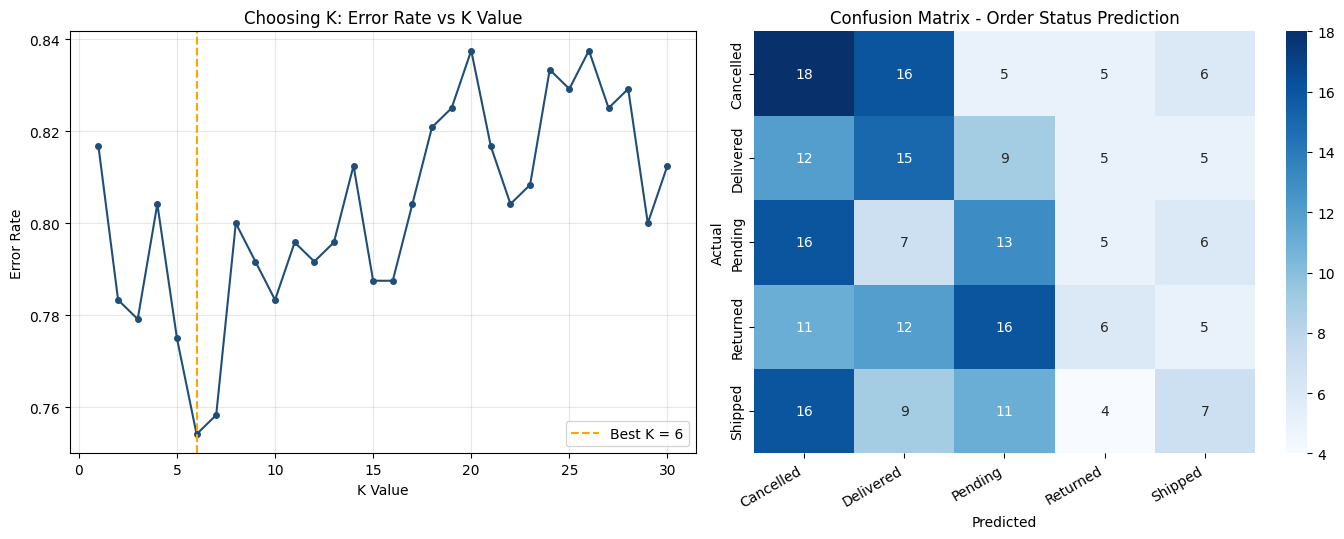


Saved visualization to orders_classification_results.png


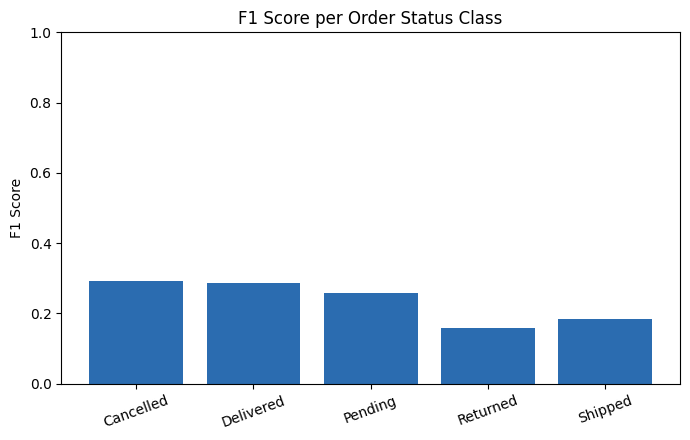

Saved per-class F1 chart to orders_f1_per_class.png

STEP 5: PREDICTING A SAMPLE ORDER
Sample features:
   Product  Quantity  UnitPrice  PaymentMethod  ItemsInCart  CouponCode  ReferralSource  TotalPrice  OrderMonth  \
0        3         5     570.62              2            7           2               3      2853.1           1   

   OrderDayOfWeek  
0               2  
Predicted OrderStatus -> Cancelled
Actual OrderStatus    -> Shipped


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    f1_score,
)

pd.set_option("display.width", 120)

# -------------------------------------------------------------------
# STEP 1: INPUT -> Load and understand the dataset
# -------------------------------------------------------------------
# If you uploaded the file directly in Colab (files.upload()), it lands in /content/
DATA_PATH = "/content/Dataset for Data Analytics.xlsx"   # <-- change path if needed (e.g. Drive path)

df = pd.read_excel(DATA_PATH)

print("=" * 60)
print("STEP 1: DATASET OVERVIEW")
print("=" * 60)
print(f"Rows: {df.shape[0]}   Columns: {df.shape[1]}")
print(df.head())
print("\nColumn types:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())
print("\nTarget class distribution (OrderStatus):")
print(df["OrderStatus"].value_counts())

# -------------------------------------------------------------------
# STEP 2: PROCESS -> Clean & prepare features
# -------------------------------------------------------------------
df_model = df.drop(columns=["OrderID", "CustomerID", "TrackingNumber", "ShippingAddress"])

df_model["CouponCode"] = df_model["CouponCode"].fillna("NoCoupon")

df_model["OrderMonth"] = df["Date"].dt.month
df_model["OrderDayOfWeek"] = df["Date"].dt.dayofweek
df_model = df_model.drop(columns=["Date"])

categorical_cols = ["Product", "PaymentMethod", "CouponCode", "ReferralSource"]
encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col])
    encoders[col] = le

target_encoder = LabelEncoder()
y = target_encoder.fit_transform(df_model["OrderStatus"])
X = df_model.drop(columns=["OrderStatus"])
feature_names = X.columns.tolist()
target_names = target_encoder.classes_

print("\n" + "=" * 60)
print("STEP 2: FEATURES USED FOR CLASSIFICATION")
print("=" * 60)
print(feature_names)

# -------------------------------------------------------------------
# STEP 3: PROCESS -> Train-Test Split
# -------------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True, stratify=y
)
print(f"\nTraining samples: {X_train.shape[0]}   Testing samples: {X_test.shape[0]}")

# -------------------------------------------------------------------
# STEP 4: PROCESS -> Feature Scaling
# -------------------------------------------------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# -------------------------------------------------------------------
# STEP 5: PROCESS -> Choosing optimal K
# -------------------------------------------------------------------
error_rates = []
k_range = range(1, 31)
for k in k_range:
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    knn_temp.fit(X_train_scaled, y_train)
    pred_temp = knn_temp.predict(X_test_scaled)
    error_rates.append(np.mean(pred_temp != y_test))

best_k = k_range[int(np.argmin(error_rates))]
print("\n" + "=" * 60)
print("STEP 3: CHOOSING OPTIMAL K")
print("=" * 60)
print(f"Best K found: {best_k} (lowest error rate = {min(error_rates):.4f})")

# -------------------------------------------------------------------
# STEP 6: PROCESS -> Train the KNN model
# -------------------------------------------------------------------
model = KNeighborsClassifier(n_neighbors=best_k)
model.fit(X_train_scaled, y_train)
predictions = model.predict(X_test_scaled)

# -------------------------------------------------------------------
# STEP 7: OUTPUT -> Evaluation
# -------------------------------------------------------------------
acc = accuracy_score(y_test, predictions)
f1 = f1_score(y_test, predictions, average="macro")
cm = confusion_matrix(y_test, predictions)

print("\n" + "=" * 60)
print("STEP 4: MODEL EVALUATION")
print("=" * 60)
print(f"Accuracy : {acc*100:.2f}%")
print(f"F1 Score (macro): {f1:.4f}")
print("\nConfusion Matrix:")
print(cm)
print("\nClassification Report:")
print(classification_report(y_test, predictions, target_names=target_names))

# -------------------------------------------------------------------
# STEP 8: Visualizations (saved to Colab's current directory)
# -------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

axes[0].plot(list(k_range), error_rates, marker="o", color="#1f4e79", markersize=4)
axes[0].axvline(best_k, color="orange", linestyle="--", label=f"Best K = {best_k}")
axes[0].set_title("Choosing K: Error Rate vs K Value")
axes[0].set_xlabel("K Value")
axes[0].set_ylabel("Error Rate")
axes[0].legend()
axes[0].grid(alpha=0.3)

sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=target_names, yticklabels=target_names, ax=axes[1]
)
axes[1].set_title("Confusion Matrix - Order Status Prediction")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")
plt.setp(axes[1].get_xticklabels(), rotation=30, ha="right")

plt.tight_layout()
plt.savefig("orders_classification_results.png", dpi=150)   # saves in /content/
plt.show()
print("\nSaved visualization to orders_classification_results.png")

# -------------------------------------------------------------------
# STEP 9: F1 score per class
# -------------------------------------------------------------------
report_dict = classification_report(y_test, predictions, target_names=target_names, output_dict=True)
per_class_f1 = {cls: report_dict[cls]["f1-score"] for cls in target_names}

plt.figure(figsize=(7, 4.5))
plt.bar(per_class_f1.keys(), per_class_f1.values(), color="#2b6cb0")
plt.title("F1 Score per Order Status Class")
plt.ylabel("F1 Score")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("orders_f1_per_class.png", dpi=150)   # saves in /content/
plt.show()
print("Saved per-class F1 chart to orders_f1_per_class.png")

# -------------------------------------------------------------------
# STEP 10: Predict on a new/unseen order example
# -------------------------------------------------------------------
sample = X.iloc[[0]].copy()
sample_scaled = scaler.transform(sample)
sample_pred = model.predict(sample_scaled)
print("\n" + "=" * 60)
print("STEP 5: PREDICTING A SAMPLE ORDER")
print("=" * 60)
print(f"Sample features:\n{sample}")
print(f"Predicted OrderStatus -> {target_names[sample_pred[0]]}")
print(f"Actual OrderStatus    -> {df.loc[0, 'OrderStatus']}")

# -------------------------------------------------------------------
# STEP 11: (Optional) download charts to your computer from Colab
# -------------------------------------------------------------------
# from google.colab import files
# files.download("orders_classification_results.png")
# files.download("orders_f1_per_class.png")